In [33]:
from examples.simple_patch_tl import q1_causal_trace, plot_heatmap
from nnsight import LanguageModel

import torch

torch.set_grad_enabled(False)

# TransformerLens

Loaded pretrained model gpt2-xl into HookedTransformer
Moving model to device:  cuda


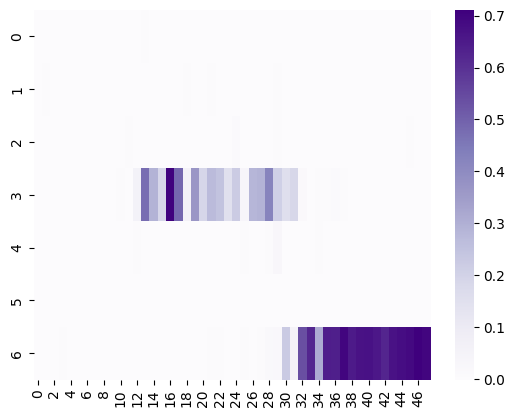

In [2]:
q1_causal_trace("resid_pre")

Loaded pretrained model gpt2-xl into HookedTransformer
Moving model to device:  cuda


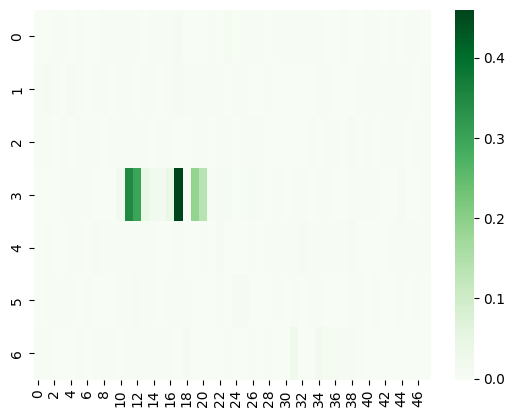

In [3]:
q1_causal_trace("mlp_post")

Loaded pretrained model gpt2-xl into HookedTransformer
Moving model to device:  cuda


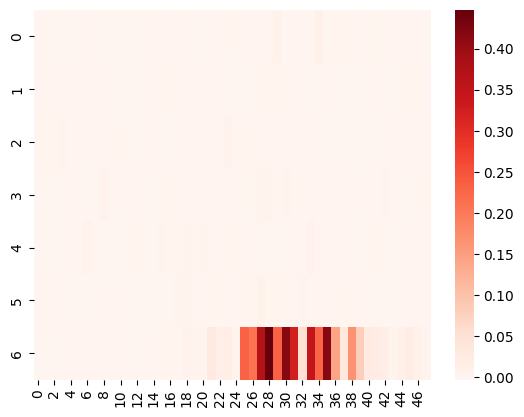

In [4]:
q1_causal_trace("attn_out")

# NNSight

In [7]:
model = LanguageModel("gpt2-xl", device_map="auto")

In [24]:
model.tokenizer.encode(" Seattle")

[7312]

In [ ]:
prompt = ("The Space Needle is located in",)
source = ("The Space Needle",)
target = "Seattle"


activation_record = {}
for layer in range(model.config.n_layer):
    with model.trace(prompt):
        activation_record[layer] = model.transformer.h[layer].input.save()

with model.trace(prompt):
    model.transformer.h[0].input[:, [1, 2, 3], :] += (
        torch.randn(1, 3, model.transformer.h[0].input.size(-1), device=model.device)
        * 0.5
    )
    probs = model.lm_head.output[:, -1].softmax(dim=1)
    corrupted_logits = probs[0, 7312].save()

patch_result = torch.zeros(6, model.config.n_layer)

for token in range(1, 7):
    for layer in range(model.config.n_layer):
        with model.trace(prompt):
            model.transformer.h[0].input[:, [1, 2, 3], :] += (
                torch.randn(
                    1, 3, model.transformer.h[0].input.size(-1), device=model.device
                )
                * 0.5
            )

            model.transformer.h[layer].input[:, token, :] = activation_record[layer][
                :, token, :
            ]

            probs = model.lm_head.output[:, -1].softmax(dim=1)

            patched_logits = (probs[0, 7312] - corrupted_logits).save()
            patch_result[token - 1, layer] = patched_logits

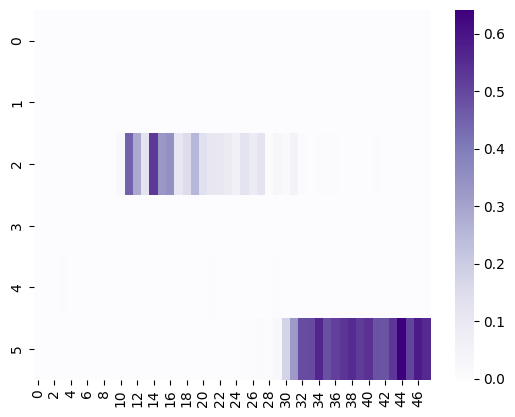

In [35]:
plot_heatmap(patch_result, "")